In [22]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math,random,os,sys, importlib, time
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde, kstest, cramervonmises, chi2, ks_2samp

ROOT = Path.cwd().resolve().parents[0]
SRC  = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
import data.utils as utils; importlib.reload(utils)
from data.utils import plot_traj, check_safety,compute_x_safety_map, compute_mu_safety_map,compute_cov_safety_map
from data.datasets import SpringDataset, make_sequence_pairs
import data.plotting as plotting
importlib.reload(plotting)
from data.plotting import plot_x_safety_map, plot_mu_safety_map,annotate_mu_shift_directions
from train.models import build_cond_gru_model, EncoderOnly
from train.training import (
    train_eval_epoch,
    train_eval_epoch_enc_only,
)
from train.eval import encode_to_latent
from train.losses import mmd2_unif, energy_distance_unif
from hypo_test.stats_tests import mmd_stat,energy_stat,perm_pvalue_two_sample,pvals_ks_cvm_to_uniform,chi2_pvalue_to_uniform
from train.training_clean import (
    DivergenceConfig,
    StabilityConfig,
    RegimeConfig,
    TrainingConfig,
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_epoch,
)
from train.training_clean import (
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_epoch,
    eval_stability_classification,
    eval_regime_batch_stats
)
import pickle, pathlib
import torch
from torch.utils.data import DataLoader
from joblib import Parallel, delayed
import copy

# Divergence configuration


# Global config
class Cfg:
    seed = 1
    n_samples = 5000
    T = 10.0
    dt = 0.05
    stride = 1
    tau = 1 # safety threshold for each trajectory, stable trajectory means \max_{t \in time_window} s(t) < \tau 
    time_window = (6, 10) # inspection window
    dist_mean = np.array([0., 0.])
    dist_cov = np.diag([1., 1.])
    batch_train = 1024
    batch_val = 1024
    epochs = 100
    lr = 3e-3
    weight_decay = 1e-5
    lr_enc = 3e-3
    weight_decay_enc = 0
    lambda_mmd = 1e-2
    d_x = 2
    d_o = 1
    d_v = 1
    d_h = 128
    hidden_enc = 512
    hidden_dec = 128
    B_bins = 20  # chi-square bins
    

# Reproducibility
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)


device: mps


## Data Overview


context X shape: (5000, 2)
Empirical stability probability: 0.9200
Target stability probabiltiy threshold (1-eta) = 0.9000 -> If Stable = 1


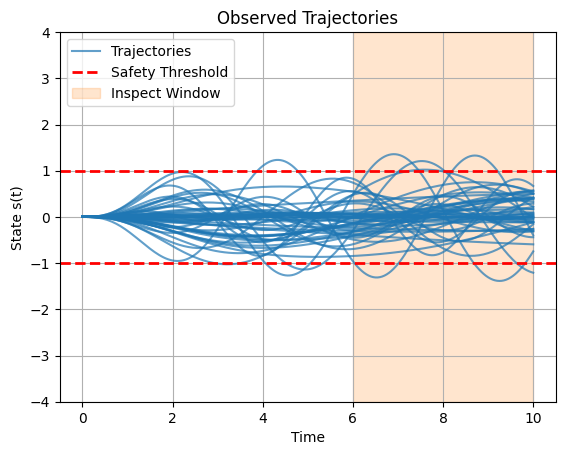

In [ ]:

z_0 = np.array([0.0, 0.0])  # baseline configuration, initial valaues for position and speed
params = SpringParams(mass=1.0, damping=1, stiffness=2.0) # system parameters \theta
seed = 1 # random seed

#### a bounded box for sampling X
low, high = -3.0, 3.0
X = sample_x(
    n_samples=Cfg.n_samples,
    dist_type="gaussian",
    params={"mean": Cfg.dist_mean, "cov": Cfg.dist_cov},
    seed=Cfg.seed,
truncate_box=(low,high)
)
print("context X shape:",X.shape)

###### return a dict with keys: dict_keys(['t', 's', 's_dot']), time (T/d_t+1 array), position (n * T/d_t+1 array), velocity (n * T/d_t+1 array)
##### simulate trajectories with context X, and external forcing type with sin wave, and initial values z_0.
traj = simulate_spring(params, t_final=Cfg.T, dt=Cfg.dt, X=X, forcing_type='sin', config=z_0)

# Check whether current configuration is stable under baseline distrtibuion X ~ N(mean, cov)
# safety_indicator = 1 if safe, 0 if unsafe
safety_indicator = check_safety(traj, threshold=Cfg.tau, window=Cfg.time_window)
p_safe = float(np.mean(safety_indicator))
print(f"Empirical stability probability: {p_safe:.4f}")

#compare the sample empiricla stability probability p_safe vs the threshold eta, if p_safe >=1-eta, we then consider the system is stable
eta = 0.1 # probability threshold for 
config_safety = 1 if p_safe >= 1.0 - eta else 0  # chance constraint
print(f"Target stability probabiltiy threshold (1-eta) = {1.0 - eta:.4f} -> If Stable = {config_safety}")
plot_traj(traj, threshold=Cfg.tau, window=Cfg.time_window,n_max=50,title='Observed Trajectories',ylim=(-4,4))


## Visualization and Understanding System Stability Under External Random Variables

In [ ]:
res_mu_safety = compute_mu_safety_map(params, t_final=T, dt=dt,
    window=Cfg.time_window,
    threshold=Cfg.tau,
    cov=Cfg.dist_cov,
    n_mu_grid=21,
    mu_limits= (-1.0, 1.0),
    n_per_mu = 4000,
    forcing_type="sin",
    config=z_0,
    eta = eta,
    truncate_X_box=(low,high),
    batch_size=2000,
    seed=0)

In [5]:
# save
out_path = ROOT / "cache" / f"res_mu_safety_tau_{tau}_eta_{eta}.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("wb") as f:
    pickle.dump(res_mu_safety, f)

# load 
out_path = ROOT / "cache" / f"res_mu_safety_tau_{tau}_eta_{eta}.pkl"
with out_path.open("rb") as f:
    res_mu_safety = pickle.load(f)

Below, we demonstrate how different values of $\mu$ for the distribution $X \sim N(\mu, \Sigma)$ impact system stability.In the visualization provided, each cell represents a specific value of $\mu$. For each value of $\mu$, we plot the stability indicator and the stability probability of trajectories generated with $X \sim N(\mu, \Sigma)$.

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Config-safety map over $\\mu$ (truncated X in $[-3,3]^2$)'}, xlabel='$\\mu_1$', ylabel='$\\mu_2$'>)

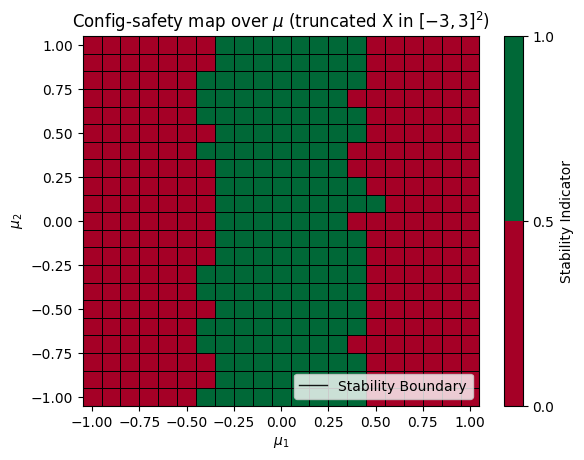

In [ ]:
# Plot indicator (0/1 per mu cell)
from matplotlib.colors import ListedColormap, BoundaryNorm

cmap_indicator = ListedColormap(["#a50026", "#006837"])   # gray, muted green
norm_indicator = BoundaryNorm([0, 0.5, 1], cmap_indicator.N)

plot_mu_safety_map(
    res_mu_safety,
    mode="indicator",
    title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
    cmap=cmap_indicator,
    norm=norm_indicator,
    show_cell_edges=True,
    linewidth=0.5,
    draw_boundary=False,
    
)

/Users/mzheng/Desktop/research/Physics-Informed-Hypo-Test/share_code/src/data/plotting.py:316: UserWarning: The following kwargs were not used by contour: 'label'
  cs = ax.contour(


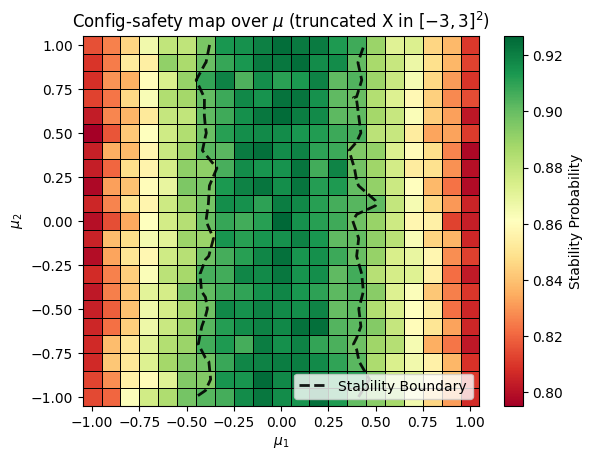

In [19]:
fig,ax= plot_mu_safety_map(
    res_mu_safety,
    mode="prob",
    title=r"Config-safety map over $\mu$ (truncated X in $[-3,3]^2$)",
    cmap="RdYlGn",
    show_cell_edges=True,
    linewidth=0.5,
    boundary_lw=2,
    boundary_color='black',
    draw_boundary=True,
    vmax=res_mu_safety['safe'].max(),
    vmin=res_mu_safety['safe'].min(),
    eta=0.1
)

In [ ]:

res_x_safety = compute_x_safety_map(params, t_final=Cfg.T, dt=Cfg.dt, window=Cfg.time_window,
                           threshold=Cfg.tau, n_grid=300, box_limits=(-3,3),
                           forcing_type="sin", config=z_0)


In [ ]:
# save
out_path = ROOT / "cache" / f"res_x_safety_tau_{Cfg.tau}_eta_{eta}.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)
with out_path.open("wb") as f:
    pickle.dump(res_x_safety, f)

#  load 
out_path = ROOT / "cache" / f"res_x_safety_tau_{Cfg.tau}_eta_{eta}.pkl"
with out_path.open("rb") as f:
    res_x_safety = pickle.load(f)

Below, we demonstrate examples of different shift patterns:

* Under the Null Hypothesis: The shift does not change the system stability.

* Under Boundary Transition: The system transitions from a stable to an unstable state.

* Under the Alternative Hypothesis: The system remains consistently unstable.

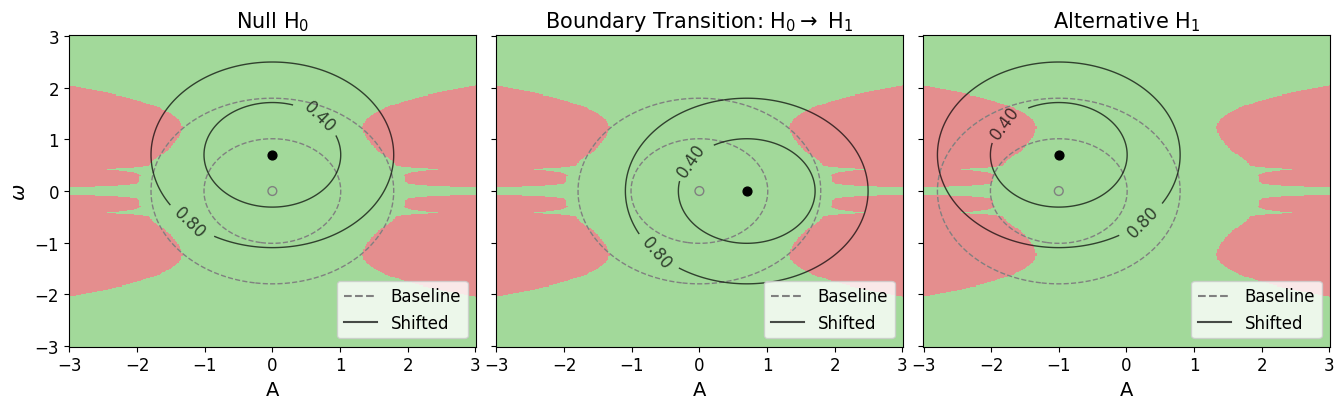

In [ ]:
from data.plotting import plot_x_safety_map, plot_mu_safety_map,annotate_mu_shift_directions,annotate_x_shift_directions,plot_x_safety_map_shift_panels

# cmap_indicator = ListedColormap(["#a50026", "#006837"])   # gray, muted green
cmap_indicator = ListedColormap(["#D95F5F", "#7BC96F"])   # gray, muted green
norm_indicator = BoundaryNorm([-0.5, 0.5, 1.5], cmap_indicator.N)
mean_test = np.array([0.,0])
cov_test = np.diag([1, 1])

fig, axes = plot_x_safety_map_shift_panels(
    res_x_safety,
    initial_positions=[(0, 0), (0, 0), (-1, 0)],
    directions=[(0, 1), (1, 0), (0, 1)],
    labels=[r"Null H$_0$", r"Boundary Transition: H$_0 \to$ H$_1$", r"Alternative H$_1$"],
    # labels=["Null H_0", "Boundary-transition H0 to H1", "Alternative H1"],
    colors = ["black", "black", "black"],
    cmap=cmap_indicator,
    norm=norm_indicator,
    cmap_alpha=0.7,
    mean=mean_test,
    cov=cov_test,
    shift_mode="distribution",
    shift_length=0.7,
    original_contour_alpha = 1,
    contour_levels=2,
    contour_mass=True,
    # contour_levels=[0.6, 0.8, 0.9],
    show_contour_labels=True,
    contour_mass_max=0.8,
    contour_color="black",
    contour_alpha=0.7,
    arrow_scale=1,
    horizontal_text_position="bottom",
    vertical_text_position="left",
    text_pad=0.2,show_arrow_text=False,
    colorbar=False,
    title_fontsize=15,
    label_fontsize=14,
    tick_fontsize=12,
    cbar_label_fontsize=14,
    cbar_tick_fontsize=12,
    
)


## Model Training

In [ ]:
##### here we specify the input data, and split into train and validation set. 
##### s is the training trajectories, shape (n_samples, T/d_t+1)
##### y is the training trajectory stability binary label (1 for stable and 0 for unstable), shape (n_samples)
##### X is the training input contexts/features, shape (n_samples, d)

s = traj["s"] 
assert X.shape[0] == s.shape[0]

o_hist,o_next = make_sequence_pairs( s=s,stride=Cfg.stride)
x_np   = X.astype(np.float32)

y = check_safety(
    traj=traj,
    threshold=Cfg.tau,
    window=Cfg.time_window,
).astype(np.float32)

print("Shapes -> X:", x_np.shape, "trajectory shape:", s.shape)

N = x_np.shape[0]
perm = np.random.RandomState(Cfg.seed).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx])

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx], y=y[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx], y=y[va_idx])

train_loader = DataLoader(
    train_ds,
    batch_size=Cfg.batch_train,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=Cfg.batch_val,
    shuffle=False,
)

# print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")



trajectory shape: (5000, 201)
Shapes -> X: (5000, 2) trajectory shape: (5000, 201)


In [ ]:
Cfg.loss_type = 'stability_asymmetric_recon'
Cfg.asym_recon_delta=3 # control the stability weight for weighted reconstruction loss
div_fn = mmd2_unif
div_kwargs = {"sigmas": None, "low_discrepancy": True}

train_cfg = TrainingConfig(
    divergence=DivergenceConfig(lambda_mmd=Cfg.lambda_mmd, fn=div_fn, kwargs=div_kwargs),
    stability=StabilityConfig(
        loss_type=Cfg.loss_type,
        threshold=Cfg.tau,
        asym_recon_delta=Cfg.asym_recon_delta,
    ),
)

baseline_model_cfg = DivergenceConfig(
    lambda_mmd=Cfg.lambda_mmd,
    fn=div_fn,
    kwargs=div_kwargs,
)

In [35]:
model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    enc_layers=2,
    dec_layers=1,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
    dropout_rnn=0.1,
).to(device)

model_enc = EncoderOnly(copy.deepcopy(model.enc)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr_enc, weight_decay=Cfg.weight_decay_enc)


def evaluate_split_metrics(loader, split_name):
    rec, div = eval_epoch(
        loader=loader,
        model=model,
        device=device,
        config=train_cfg,
    )
    total = rec + Cfg.lambda_mmd * div
    metrics = {
        f"{split_name}_recon": float(rec),
        f"{split_name}_divergence": float(div),
        f"{split_name}_total_loss": float(total),
    }
    if train_cfg.stability.threshold is not None:
        cls = eval_stability_classification(
            loader=loader,
            model=model,
            device=device,
            stability=train_cfg.stability,
        )
        metrics.update(
            {
                f"{split_name}_safety_acc": cls["overall_acc"],
                f"{split_name}_safety_y1_acc": cls["y1_correct_frac"],
                f"{split_name}_safety_y0_acc": cls["y0_correct_frac"],
                f"{split_name}_frac_y1": cls["frac_y1"],
                f"{split_name}_frac_y0": cls["frac_y0"],
            }
        )
    return metrics


@torch.no_grad()
def build_reconstruction_snapshot(loader, split_name, max_samples=8):
    batch = next(iter(loader))
    x_b, o_hist_b, o_next_b, y_b = batch
    non_blocking = device.type == "cuda"
    x_b = x_b[:max_samples].to(device, non_blocking=non_blocking)
    o_hist_b = o_hist_b[:max_samples].to(device, non_blocking=non_blocking)
    o_next_b = o_next_b[:max_samples].to(device, non_blocking=non_blocking)
    y_slice = None if y_b is None else y_b[:max_samples]

    model.eval()
    o_hat_b, _ = model(x_b, o_hist_b)
    per_sample_mse = torch.mean((o_hat_b - o_next_b) ** 2, dim=(1, 2))

    snapshot = pd.DataFrame(
        {
            "split": split_name,
            "sample_idx": np.arange(x_b.shape[0]),
            "recon_mse": per_sample_mse.detach().cpu().numpy(),
            "x": list(x_b.detach().cpu().numpy()),
            "o_hist": list(o_hist_b.detach().cpu().numpy()),
            "o_next_true": list(o_next_b.detach().cpu().numpy()),
            "o_next_pred": list(o_hat_b.detach().cpu().numpy()),
        }
    )
    if y_slice is not None:
        snapshot["y"] = list(np.asarray(y_slice[: x_b.shape[0]]))
    return snapshot


history = []
best_val_mmd = float("inf")
best_state = None
use_val = val_loader is not None

for epoch in range(1, Cfg.epochs + 1):
    tr_loss, val_rec, val_div = train_eval_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=opt,
        device=device,
        config=train_cfg,
        val_loader=val_loader if use_val else None,
    )

    tr_div_enc, val_div_enc = train_eval_epoch_enc_only(
        model_enc=model_enc,
        train_loader=train_loader,
        optimizer=opt_enc,
        device=device,
        divergence=baseline_model_cfg,
        val_loader=val_loader if use_val else None,
    )

    train_metrics = evaluate_split_metrics(train_loader, "train")
    val_metrics = evaluate_split_metrics(val_loader, "val") if use_val else {
        "val_recon": None,
        "val_divergence": None,
        "val_total_loss": None,
        "val_safety_acc": None,
        "val_safety_y1_acc": None,
        "val_safety_y0_acc": None,
        "val_frac_y1": None,
        "val_frac_y0": None,
    }

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_loss": (None if val_rec is None or val_div is None else val_rec + Cfg.lambda_mmd * val_div),
        "val_recon_raw": val_rec,
        "val_divergence_raw": val_div,
        "train_div (enc-only)": tr_div_enc,
        "val_divergence (enc-only)": val_div_enc,
        **train_metrics,
        **val_metrics,
    })

    if use_val and val_div is not None and val_div < best_val_mmd:
        best_val_mmd = val_div
        best_state = model.state_dict()

    if epoch % 10 == 0 or epoch == 1:
        msg = (
            f"[{epoch:02d}] train-loss={tr_loss:.6f}"
            f" train-recon={train_metrics['train_recon']:.6f}"
            f" train-acc={train_metrics.get('train_safety_acc', float('nan')):.4f}"
        )
        if use_val:
            msg += (
                f"  val-recon={val_metrics['val_recon']:.6f}"
                f"  val-divergence={val_metrics['val_divergence']:.6f}"
                f"  val-acc={val_metrics.get('val_safety_acc', float('nan')):.4f}"
                f"  train-divergence (enc)={tr_div_enc:.6f}"
                f"  val-divergence (enc)={val_div_enc:.6f}"
            )
        print(msg)

if use_val and best_state is not None:
    model.load_state_dict(best_state)


[01] train-loss=0.183803 train-recon=0.072506 train-acc=0.9157  val-recon=0.068146  val-divergence=0.027391  val-acc=0.9350  train-divergence (enc)=0.196502  val-divergence (enc)=0.027301
[10] train-loss=0.003758 train-recon=0.001781 train-acc=0.9310  val-recon=0.001721  val-divergence=0.036132  val-acc=0.9550  train-divergence (enc)=0.005870  val-divergence (enc)=0.003588
[20] train-loss=0.000425 train-recon=0.000293 train-acc=0.9613  val-recon=0.000293  val-divergence=-0.000145  val-acc=0.9740  train-divergence (enc)=-0.000082  val-divergence (enc)=-0.000444
[30] train-loss=0.000106 train-recon=0.000092 train-acc=0.9580  val-recon=0.000090  val-divergence=-0.000410  val-acc=0.9740  train-divergence (enc)=0.000868  val-divergence (enc)=-0.000049
[40] train-loss=0.000062 train-recon=0.000058 train-acc=0.9629  val-recon=0.000057  val-divergence=-0.000522  val-acc=0.9740  train-divergence (enc)=0.000773  val-divergence (enc)=-0.000616
[50] train-loss=0.000047 train-recon=0.000041 train-a

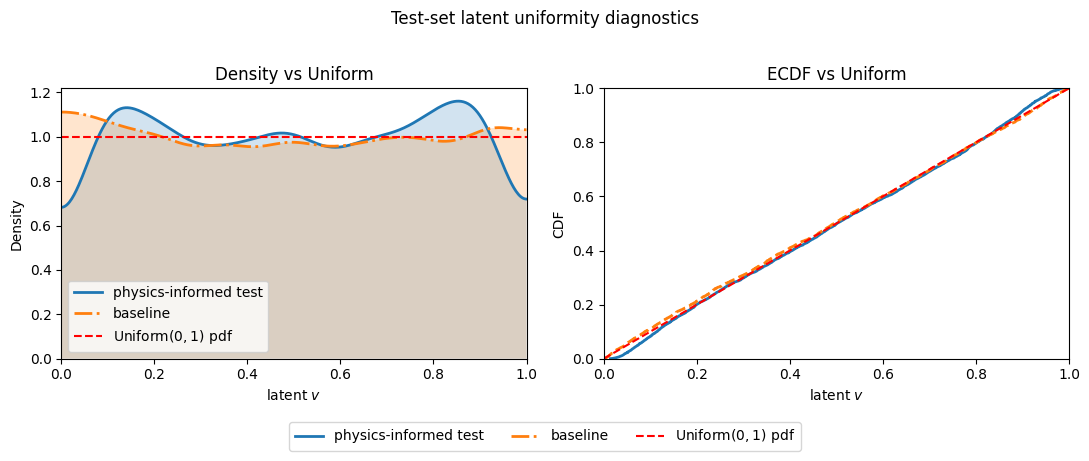

In [ ]:
##### plot the trained latent distribution of proposed method vs the baseline method with regularization only encoder.
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

def ks_to_uniform(x):
    x = np.sort(x)
    n = len(x)
    Fn = np.arange(1, n + 1) / n
    return float(np.max(np.abs(Fn - x)))


X_splits = {
    "X_train": x_np[tr_idx],
    "X_val":   x_np[va_idx],
    "X_test":  sample_x(
        n_samples=2000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=1,
    ).astype(np.float32),
}


# -----------------------
# 1) compute latents once
# -----------------------
v_np  = encode_to_latent(model,     X_splits["X_train"], device)[:, 0]
v0_np = encode_to_latent(model_enc, X_splits["X_train"], device)[:, 0]


# -----------------------
# 2) make 2-panel plot
# -----------------------
grid = np.linspace(0, 1, 400)
# kde_v  = gaussian_kde(v_np)(grid)
# kde_v0 = gaussian_kde(v0_np)(grid)

x1, y1 = ecdf(v_np)
x2, y2 = ecdf(v0_np)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

# (a) KDE vs Uniform pdf

def reflective_kde_01(samples, grid, bw_method="scott"):
    x = np.asarray(samples, dtype=float)
    x = x[np.isfinite(x)]
    x = x[(x >= 0.0) & (x <= 1.0)]
    if x.size < 2:
        raise ValueError("Need at least 2 valid samples in [0,1].")

    base = gaussian_kde(x, bw_method=bw_method)

    # Reflection at both boundaries 0 and 1
    dens = base(grid) + base(-grid) + base(2.0 - grid)

    # Optional normalization on [0,1]
    area = np.trapz(dens, grid)
    if area > 0:
        dens = dens / area
    return dens
kde_v = reflective_kde_01(v_np, grid)
kde_v0 = reflective_kde_01(v0_np, grid)

# v: proposed latent samples in [0,1]
# v0: baseline latent samples in [0,1]
ax = axes[0]
ax.plot(grid, kde_v,  linewidth=2, label="physics-informed test")
ax.fill_between(grid, 0, kde_v, alpha=0.20)
ax.plot(grid, kde_v0, linewidth=2, linestyle="-.", label="baseline")
ax.fill_between(grid, 0, kde_v0, alpha=0.20)
ax.axhline(1.0, linestyle="--", color="red", label=r"Uniform$(0,1)$ pdf")
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("Density")
ax.set_title("Density vs Uniform")
ax.legend()


# (b) ECDF vs Uniform CDF
ax = axes[1]
ax.plot(x1, y1, linewidth=2, label="proposed (ECDF)")
ax.plot(x2, y2, linewidth=2, linestyle="--", label="baseline (ECDF)")
ax.plot([0, 1], [0, 1], linestyle="--", color="red", label=r"Uniform$(0,1)$ CDF")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("CDF")
ax.set_title("ECDF vs Uniform")

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
fig.legend(handles , labels , loc="lower center", ncol=3, frameon=True,bbox_to_anchor=(0.5, -0.1),)
# plt.legend()

fig.suptitle("Test-set latent uniformity diagnostics", y=1.02)
fig.tight_layout()
plt.show()


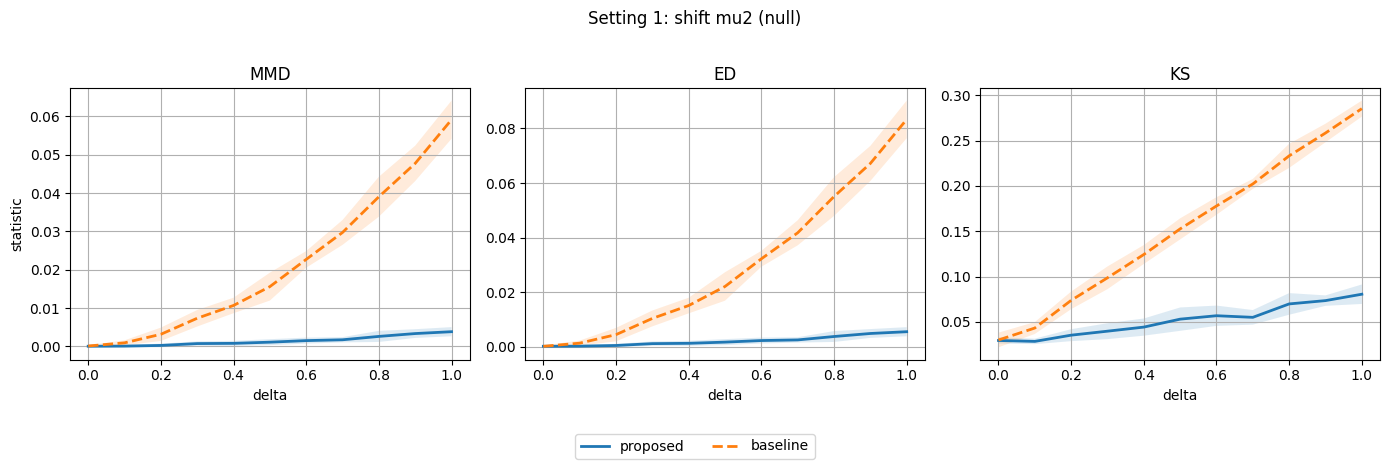

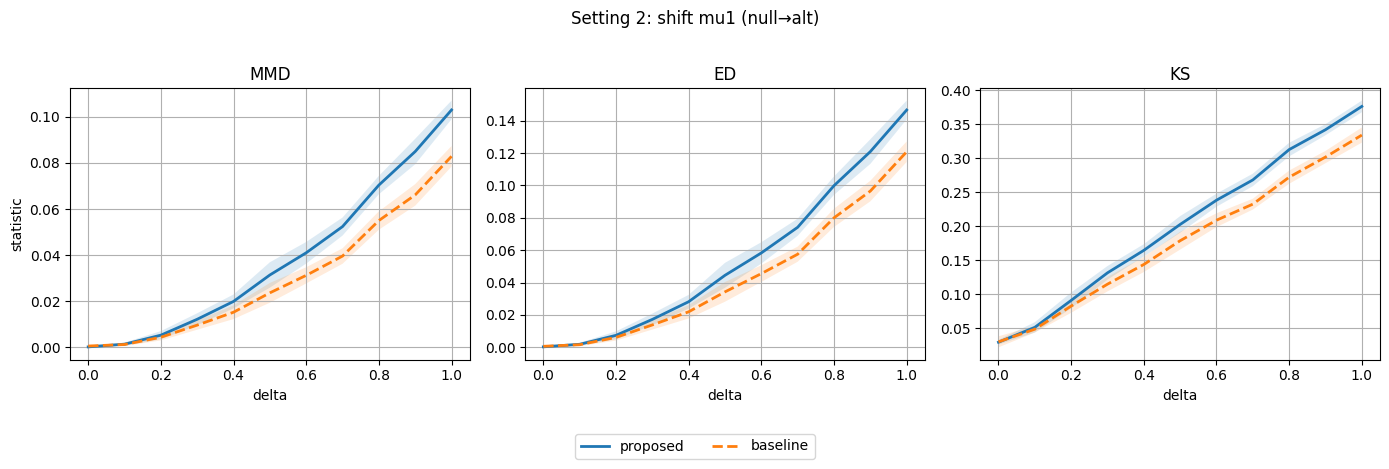

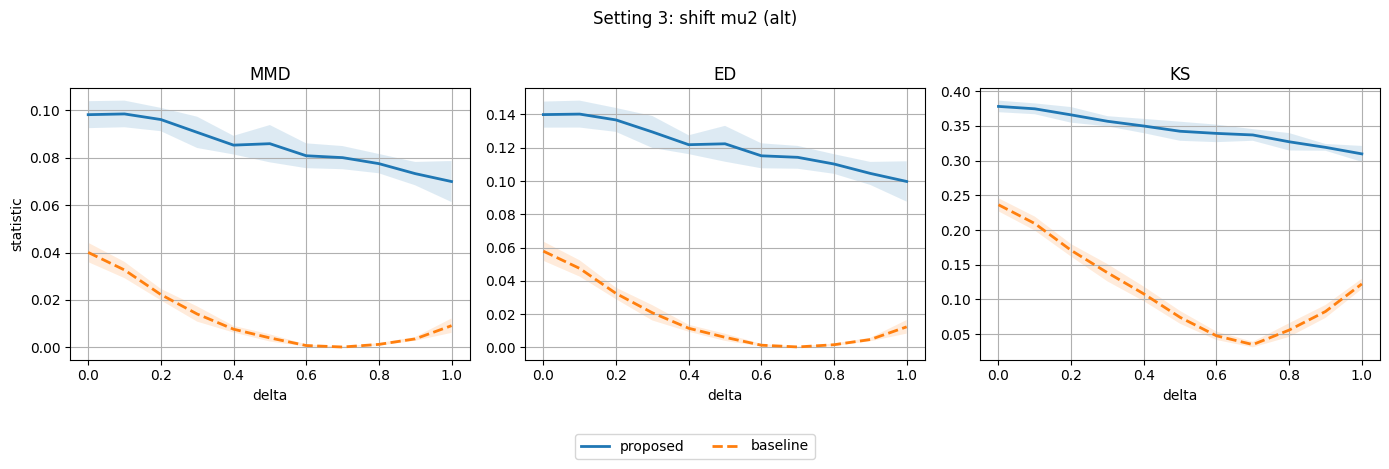

In [ ]:
##### for the 3 settings mentioned above in the visualization panels, 
# plot the empirical rejection rate in each row, where each col corresponds to different two sample test methods.

@torch.no_grad()
def divergences(v_np, device, ref_u=None):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    if ref_u is None:
        ref_u = torch.rand_like(v)
    mmd = mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item()
    ed  = energy_distance_unif(v.cpu(), ref_u.cpu()).item()
    ks  = ks_to_uniform(v_np)
    return mmd, ed, ks

def sweep_direction(mu_base, direction, deltas, n_samples=2000, truncate_box=None, seed=1, n_reps=10):
    rows = []
    rng = np.random.default_rng(seed)
    for delta in deltas:
        mu = np.asarray(mu_base, float) + delta * np.asarray(direction, float)
        rep_stats = []
        for _ in range(n_reps):
            s = int(rng.integers(0, 2**32 - 1))
            X = sample_x(
                n_samples=n_samples,
                dist_type="gaussian",
                params={"mean": mu, "cov": np.diag([1., 1.])},
                seed=s,
                truncate_box=truncate_box,
            ).astype(np.float32)

            ref_u = torch.rand((n_samples, 1), device=device)
            v_prop = encode_to_latent(model,     X, device)[:, 0]
            v_base = encode_to_latent(model_enc, X, device)[:, 0]

            mmd_p, ed_p, ks_p = divergences(v_prop, device, ref_u=ref_u)
            mmd_b, ed_b, ks_b = divergences(v_base, device, ref_u=ref_u)
            rep_stats.append((mmd_p, mmd_b, ed_p, ed_b, ks_p, ks_b))

        rep_stats = np.array(rep_stats)
        rows.append({
            "delta": delta,
            "mu1": mu[0], "mu2": mu[1],
            "mmd_prop": rep_stats[:,0].mean(), "mmd_base": rep_stats[:,1].mean(),
            "ed_prop":  rep_stats[:,2].mean(), "ed_base":  rep_stats[:,3].mean(),
            "ks_prop":  rep_stats[:,4].mean(), "ks_base":  rep_stats[:,5].mean(),
            "mmd_prop_std": rep_stats[:,0].std(), "mmd_base_std": rep_stats[:,1].std(),
            "ed_prop_std":  rep_stats[:,2].std(), "ed_base_std":  rep_stats[:,3].std(),
            "ks_prop_std":  rep_stats[:,4].std(), "ks_base_std":  rep_stats[:,5].std(),
        })
    return pd.DataFrame(rows)

def plot_metrics_row(df, setting_title):
    metrics = ["mmd", "ed", "ks"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(df["delta"], df[f"{metric}_prop"], lw=2, label="proposed")
        ax.plot(df["delta"], df[f"{metric}_base"], lw=2, ls="--", label="baseline")
        ax.fill_between(df["delta"],
                        df[f"{metric}_prop"] - df[f"{metric}_prop_std"],
                        df[f"{metric}_prop"] + df[f"{metric}_prop_std"],
                        alpha=0.15)
        ax.fill_between(df["delta"],
                        df[f"{metric}_base"] - df[f"{metric}_base_std"],
                        df[f"{metric}_base"] + df[f"{metric}_base_std"],
                        alpha=0.15)
        ax.set_xlabel("delta"); ax.set_title(metric.upper()); ax.grid(True)
    axes[0].set_ylabel("statistic")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(setting_title, y=1.02)
    fig.tight_layout()
    plt.show()

@torch.no_grad()
def stats_vs_unif(v_np):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    ref_u = torch.rand_like(v)
    mmd = mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item()
    ed  = energy_distance_unif(v.cpu(), ref_u.cpu()).item()
    ks  = ks_to_uniform(v_np)
    return mmd, ed, ks

# ---------- run sweeps with repetition ----------
# deltas = np.round(np.arange(0.0, 1.01, 0.1), 2)
deltas = np.linspace(0,1,11)
truncate_box = (-3.0, 3.0)
n_reps = 10

# Setting 1: shift mu2 under null
df1 = sweep_direction(mu_base=(0,0), direction=(0,1), deltas=deltas, truncate_box=truncate_box, n_reps=n_reps)
plot_metrics_row(df1, "Setting 1: shift mu2 (null)")

# Setting 2: shift mu1 null→alt, cross decision boundary at 0.7
df2 = sweep_direction(mu_base=(0,0), direction=(1,0), deltas=deltas, truncate_box=truncate_box, n_reps=n_reps)
plot_metrics_row(df2, "Setting 2: shift mu1 (null→alt)")

# Setting 3: shift mu2 from mu1=-1 (alt)
df3 = sweep_direction(mu_base=(-1,0), direction=(0,1), deltas=deltas, truncate_box=truncate_box, n_reps=n_reps)
plot_metrics_row(df3, "Setting 3: shift mu2 (alt)")

